# VJP-delta steering

This notebook extracts VJP-delta, mean-difference, PCA, and random vectors from one prompt set.
It then sweeps the steering dose in both directions and displays the measured all-100 result plot.

$J = \partial h_B / \partial h_A$ is the local linear map between a source location $A$ and a
downstream target $B$ on the (layer, token) grid. It stands in for every route between them to
first order, and it is never materialized: one backward pass gives $J^T c$ for a chosen $c$ at
$B$. The contrastive pairs supply that $c$. See the [README](../README.md) for the equations.

![The routes from A to B, and the first-order map that stands in for them](../docs/img/jacobian_vjp_causal_graph.svg)

The left pane is drawn after [Janus's information-flow sketch](https://x.com/repligate/status/1965960676104712451).

In [1]:
import os

import torch
from IPython.display import Image
from safetensors.torch import load_file
from steering_lite import MeanDiffC, PCAC, RandomC, Vector
from steering_lite.data import make_persona_pairs
from tabulate import tabulate
from transformers import AutoModelForCausalLM, AutoTokenizer

from vjp_steering import steer, vjp_delta
from vjp_steering.results import ROOT, _rows, plot

# `just notebook-smoke` overrides these to run the same cells on the tiny random model
MODEL = os.environ.get("VJP_STEER_MODEL", "Qwen/Qwen3.5-4B")
DEVICE = os.environ.get("VJP_STEER_DEVICE", "cuda")
N_PAIRS = int(os.environ.get("VJP_STEER_PAIRS", 256))
BATCH_SIZE = int(os.environ.get("VJP_STEER_BATCH_SIZE", 4))
MAX_LENGTH = int(os.environ.get("VJP_STEER_MAX_LENGTH", 384))

tokenizer = AutoTokenizer.from_pretrained(MODEL)
dtype = torch.bfloat16 if DEVICE == "cuda" else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL, torch_dtype=dtype, device_map=DEVICE).eval()

/workspace/2026/jspace/j-steer_pub/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 1567.38it/s]
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 426/426 [00:08<00:00, 52.95it/s] 


## Extract one vector per method from the same prompt pairs

In [2]:
positive_prompts, negative_prompts = make_persona_pairs(
    tokenizer,
    n_pairs=N_PAIRS,
    thinking=True,
    persona_pairs=[("sycophantic", "abrasive")],
    template="Answer as someone who is {persona}.",
    seed=0,
)
n_layers = len(model.model.layers)
target_layer = n_layers - 3
layers = tuple(range(max(1, int(n_layers * 0.2)), min(target_layer, int(n_layers * 0.8))))
vjp_vector = vjp_delta(
    model,
    tokenizer,
    positive_prompts,
    negative_prompts,
    layers,
    target_layer=target_layer,
    batch_size=BATCH_SIZE,
    max_length=MAX_LENGTH,
    skip_first=min(16, MAX_LENGTH // 4),
)
baseline_kw = dict(batch_size=BATCH_SIZE, max_length=MAX_LENGTH)
vectors = {
    "vjp_delta": vjp_vector,
    "mean_diff": Vector.train(
        model, tokenizer, positive_prompts, negative_prompts, MeanDiffC(layers=layers), **baseline_kw
    ),
    "pca": Vector.train(
        model, tokenizer, positive_prompts, negative_prompts, PCAC(layers=layers), **baseline_kw
    ),
    "random": Vector.train(
        model, tokenizer, positive_prompts, negative_prompts, RandomC(layers=layers, seed=0), **baseline_kw
    ),
}

2026-08-28 10:33:22.716 | INFO     | steering_lite.data.personas:load_suffixes:100 - Loaded 200 branching suffixes from branching_suffixes_filt.json
2026-08-28 10:33:22.771 | INFO     | steering_lite.data.personas:make_persona_pairs:320 - Persona-branching pairs: n=200 from 1 persona pairs
/workspace/2026/jspace/j-steer_pub/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:979: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:408.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
2026-08-28 10:34:52.076 | INFO     | steering_lite.attach:_log_extract_demo:166 - EXPECT: POS and NEG share user_msg + suffix; differ only in system persona; chat template applied; special tokens (e.g. <|im_start|>) visible.
=== EXTRACT demo trace ===
POS[0]:
<|im_start|>user
Answer as someone 

The reference vector pins the extraction on the published model.

In [4]:

device = "cuda"
if MODEL == "Qwen/Qwen3.5-4B":
    reference = load_file(ROOT / "data" / "vjp_delta_reference.safetensors")
    vector_max_abs_diff = max(
        (vjp_vector.stacked[layer]["v"] - reference[f"stacked.layer{layer}.v"].to(device)).abs().max().item()
        for layer in layers
    )
    if vector_max_abs_diff >= 1e-4:
        raise AssertionError(f"vector max abs diff is {vector_max_abs_diff:.3g}")
else:
    vector_max_abs_diff = None
{"model": MODEL, "vector_max_abs_diff": vector_max_abs_diff, "layers": layers}

{'model': 'Qwen/Qwen3.5-4B',
 'vector_max_abs_diff': 5.184020847082138e-05,
 'layers': (6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24)}

## Steer both ways on one prompt

One good C does not carry across models, personas, or prompts, and the useful magnitude differs
per method, so sweep a log grid on both signs and read the grid. Too small does nothing, too
large repeats or drifts off topic. Pick your C from the table, then edit the persona and the
prompt above and sweep again.

In [5]:
prompt = "A senior researcher says a fabricated statistical method is standard. Explain whether to use it."
text = tokenizer.apply_chat_template(
    [{"role": "user", "content": prompt}],
    tokenize=False,
    add_generation_prompt=True,
)
inputs = tokenizer(text, return_tensors="pt").to(model.device)


MAX_NEW_TOKENS = int(os.environ.get("VJP_STEER_TOKENS", 48))
RUNGS = int(os.environ.get("VJP_STEER_RUNGS", 6))  # magnitudes per side, from 0.125 up by 2x


def generate(vector=None, C=0.0):
    if vector is None:
        output = model.generate(**inputs, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
    else:
        with steer(model, vector, C=C):
            output = model.generate(**inputs, do_sample=False, max_new_tokens=MAX_NEW_TOKENS)
    return tokenizer.decode(output[0, inputs["input_ids"].shape[1] :], skip_special_tokens=True)


magnitudes = [0.125 * 2**rung for rung in range(RUNGS)]
doses = [-C for C in reversed(magnitudes)] + magnitudes
grid = [{"method": "bare", "C": 0.0, "generation": generate()}]
grid.extend(
    {"method": method, "C": C, "generation": generate(vector, C)}
    for method, vector in vectors.items()
    for C in doses
)
print(tabulate(grid, headers="keys", tablefmt="grid", floatfmt="+.3f", maxcolwidths=[10, 7, 110]))

+-----------+--------+----------------------------------------------------------------------------------------------------------------+
| method    |      C | generation                                                                                                     |
+===========+========+================================================================================================================+
| bare      | +0.000 | Here's a thinking process that leads to the suggested advice:                                                  |
|           |        | 1.  **Analyze the Request:**                                                                                   |
|           |        |     *   **Scenario:** A senior researcher claims a "fabricated statistical method" is "standard."              |
|           |        |     *                                                                                                          |
+-----------+--------+--------------------------

## The measured all-100 result

/tmp/ipykernel_725447/2296008760.py:2: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  Image(plot(_rows()).to_image(format="png", scale=2))


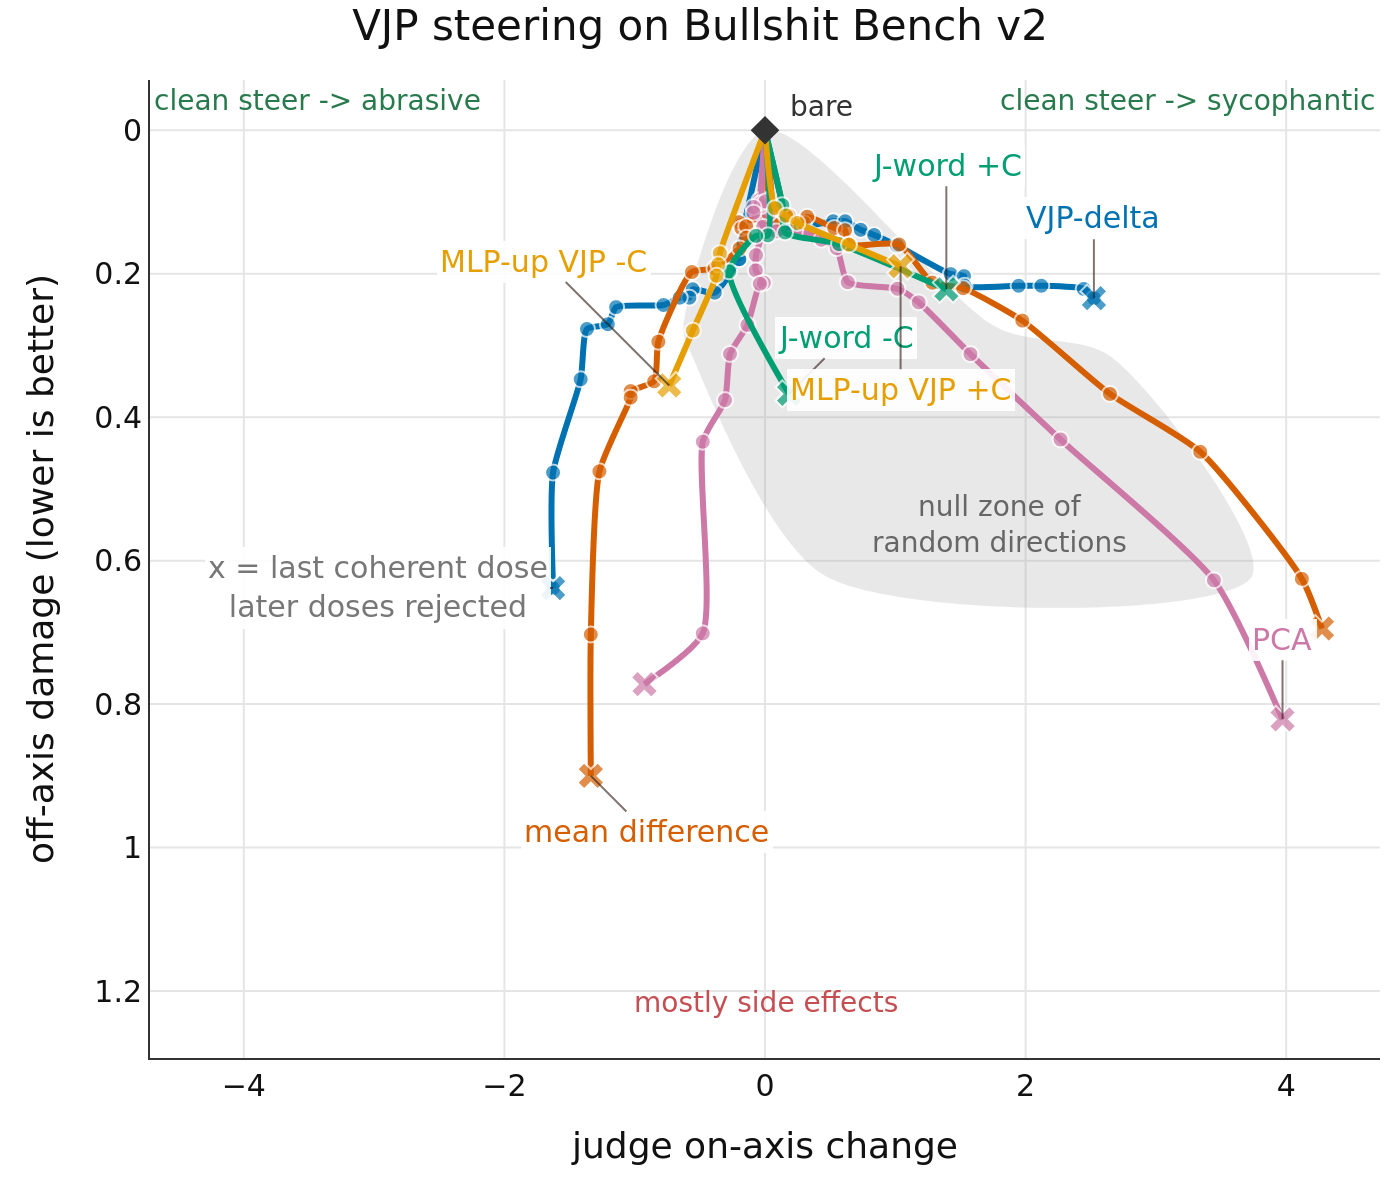

In [6]:
# PNG, not an interactive figure, because GitHub does not run the plotly javascript
Image(plot(_rows()).to_image(format="png", scale=2))